# Guia: padding por `lengths` antes del backbone


## 1. Imports

In [1]:
from pathlib import Path 
import os
import sys
import math

import torch as tr
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [2]:
def repo_root():
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / 'src').exists() and (p / 'data').exists():
            return p.resolve()
    raise RuntimeError('Run this notebook from inside the repo.')

ROOT = repo_root()
os.chdir(ROOT)
sys.path.insert(0, str(ROOT)) 

# collate_fn desde `src.data`


In [3]:
from src.data import pad_batch


# Model

In [4]:
from src.diffusion import DiffusionModel


# Implementacion


In [5]:
from src.data import build_dataloader
from src.layers.simpleunet import SimpleUNet
from src.diffusion import DiffusionModel
tr.set_printoptions(precision=4, sci_mode=False)


## 2. Cargar un batch con padding

In [49]:
# LOAD CONFIG
# configs/train/default.yaml
import yaml
config = yaml.safe_load((ROOT / 'configs' / 'train' / 'default.yaml').read_text())
config["training"]["max_epochs"] = 1
config["training"]["batch_size"] = 2
config["training"]["num_workers"] = 0
config["data"]["base_path"] = "data/ArchiveII.csv"

In [ ]:

loader = build_dataloader(config, partition="train", shuffle=True)
# loader = DataLoader(dataset, batch_size=4, shuffle=False, collate_fn=pad_batch, num_workers=0)

for batch_id, batch in enumerate(loader):
    
    max_len = batch['contact_oh'].shape[-1]
    idx = next((i for i, l in enumerate(batch['length']) if l < 0.9 * max_len), None)
    if idx is not None:
        break

seq_len = batch['length'][idx]
print('batch:', batch_id)
print('lengths:', batch['length'])
print('sample idx:', idx, 'seq_len:', seq_len, 'max_len:', max_len)

batch: 0
lengths: [402, 450]
sample idx: 0 seq_len: 402 max_len: 452


In [56]:
id = "srp_Dein.geot._CP000359"
loader = build_dataloader(config, partition="train", shuffle=True)


idx = None
flag = False
for batch_id, batch in enumerate(loader):
   for seq_id in range(len(batch['length'])): 
    
      if batch['id'][seq_id] == id:
         idx = seq_id
         flag = True

      if flag: break
   if flag: break
         
seq_len = batch['length'][idx]
print('batch:', batch_id)
print('lengths:', batch['length'])
print('id',batch["id"][idx],'sample idx:', idx, 'seq_len:', seq_len, 'max_len:', max_len)

batch: 841
lengths: [76, 32]
id srp_Dein.geot._CP000359 sample idx: 1 seq_len: 32 max_len: 452


## 3. Ver el padding real

valid pixel: tensor([1., 0.])
evaluation at seq_len: 32
padded pixel: tensor([1., 0.])
mask padded pixel: tensor(False)
lengths_real: [32]


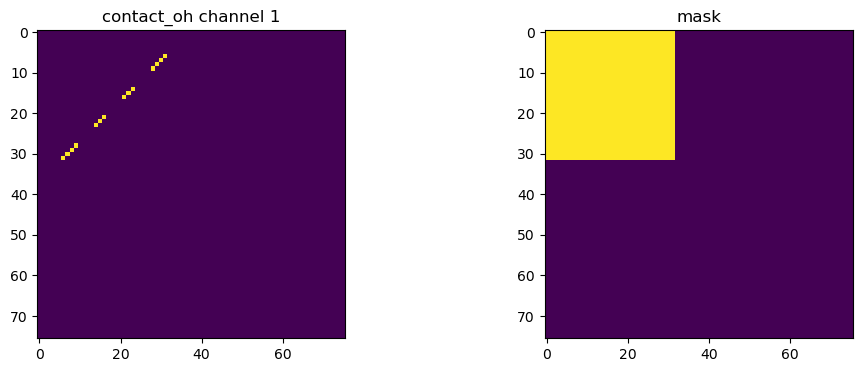

In [57]:
x0_real = batch['contact_oh'][idx:idx + 1].float()
mask_real = batch['mask'][idx:idx + 1]
# lengths_real = [int(seq_len)]
lengths_real = [int(32)]
cond = batch['conditioning'][idx:idx + 1].float()
contact_real = x0_real[0]
mask2d = mask_real[0, 0]

print('valid pixel:', contact_real[:, 0, 0])
print('evaluation at seq_len:', seq_len)
print('padded pixel:', contact_real[:, seq_len, seq_len])
print('mask padded pixel:', mask2d[seq_len, seq_len])
print('lengths_real:', lengths_real)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(contact_real[1])
axes[0].set_title('contact_oh channel 1')
axes[1].imshow(mask2d)
axes[1].set_title('mask')
plt.show()


## 4. `q_pred` mantiene probabilidades finitas en el padding


In [67]:
weights_path = "/home/gkulemeyer/Documents/Repos/RNADiffusion/logs/ArchiveII_simfold_512/sim80/t25/vb_stochastic/train/checkpoints/best.ckpt"
weights = tr.load(weights_path, map_location='cpu')
weights.keys()

dict_keys(['epoch', 'global_step', 'pytorch-lightning_version', 'state_dict', 'loops', 'callbacks', 'optimizer_states', 'lr_schedulers', 'MixedPrecision', 'hparams_name', 'hyper_parameters'])

q valid pixel: tensor([    1.0000,     0.0000])
q padded pixel: tensor([    1.0000,     0.0000])


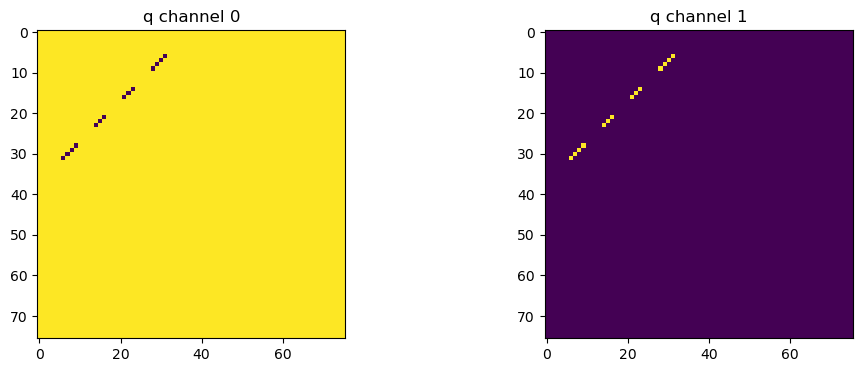

In [69]:
model = DiffusionModel(
    num_classes=2,
    time_steps=25,
    model=SimpleUNet,
    in_channels=18,
    out_channels=2,
    base_dim=64,
).eval()
# model.load_state_dict(tr.load(weights_path, map_location='cpu'))

time0 = tr.tensor([0])
q = model.q_pred(x0_real, time0)

print('q valid pixel:', q[0, :, 0, 0])
print('q padded pixel:', q[0, :, seq_len, seq_len])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(q[0, 0])
axes[0].set_title('q channel 0')
axes[1].imshow(q[0, 1])
axes[1].set_title('q channel 1')
plt.show()

## 5. Saneo localizado justo antes del backbone usando `lengths`


In [70]:
q_sum = q.sum(dim=1)

print('sum valid pixel:', q_sum[0, 0, 0])
print('sum padded pixel:', q_sum[0, seq_len, seq_len])
print('q finite in valid region:', tr.isfinite(q[:, :, :seq_len, :seq_len]).all())
print('q finite in padding:', tr.isfinite(q[0, :, seq_len, seq_len]).all())


sum valid pixel: tensor(1.)
sum padded pixel: tensor(1.)
q finite in valid region: tensor(True)
q finite in padding: tensor(True)


## 6. Forward diffusion + loss solo en pixeles validos


In [71]:
time = tr.tensor([model.time_steps // 2])
q = model.q_pred(x0_real, time)
print(f"q shape: {q.shape}")
xt = model.q_sample(x0_real, time, lengths=lengths_real)
print(f"xt shape: {xt.shape}")
raw_post = model.q_pred(x0_real, tr.clamp(time - 1, min=0)) * model.q_step(xt, time)
print(f"raw_post shape: {raw_post.shape}")
post = model.q_posterior(x0_real, xt, time)
print(f"post shape: {post.shape}")
xt_backbone, cond_backbone = model._prepare_backbone_inputs(xt, cond, lengths=lengths_real)
pred_x0 = model.predict_start(xt, time, cond, lengths=lengths_real)
vlb = model.compute_vlb(x0_real, xt, time, cond, lengths=lengths_real)
print(xt_backbone.shape, cond_backbone.shape, pred_x0.shape)
print('xt padded before backbone:', xt[0, seq_len, seq_len])
print('xt padded at backbone:', xt_backbone[0, :, seq_len, seq_len])
print('conditioning padded before backbone:', cond[0, :4, seq_len, seq_len])
print('conditioning padded at backbone:', cond_backbone[0, :4, seq_len, seq_len])
print('predict_start padded:', pred_x0[0, :, seq_len, seq_len], 'sum =', pred_x0[0, :, seq_len, seq_len].sum())
print('vlb finite:', tr.isfinite(vlb).all(), 'value =', vlb)


q shape: torch.Size([1, 2, 76, 76])
xt shape: torch.Size([1, 76, 76])
raw_post shape: torch.Size([1, 2, 76, 76])
post shape: torch.Size([1, 2, 76, 76])
torch.Size([1, 2, 76, 76]) torch.Size([1, 16, 76, 76]) torch.Size([1, 2, 76, 76])
xt padded before backbone: tensor(0)
xt padded at backbone: tensor([1., 0.])
conditioning padded before backbone: tensor([0., 0., 0., 0.])
conditioning padded at backbone: tensor([0., 0., 0., 0.])
predict_start padded: tensor([0.5229, 0.4771], grad_fn=<SelectBackward0>) sum = tensor(1., grad_fn=<SumBackward0>)
vlb finite: tensor(True) value = tensor([0.0358], grad_fn=<StackBackward0>)


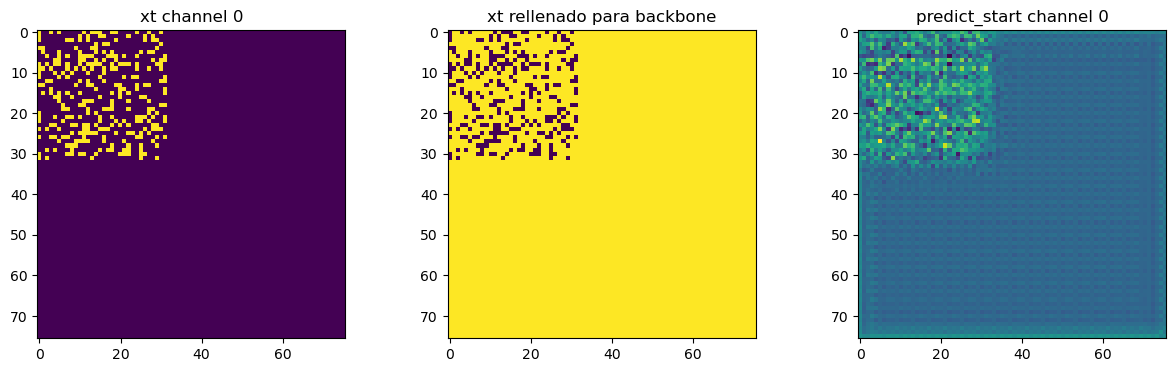

In [72]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(xt[0])
axes[0].set_title('xt channel 0')
axes[1].imshow(xt_backbone[0, 0])
axes[1].set_title('xt rellenado para backbone')
axes[2].imshow(pred_x0[0, 1].detach().numpy())
axes[2].set_title('predict_start channel 0')
plt.show()


 shapes: q: torch.Size([1, 2, 76, 76]), xt: torch.Size([1, 76, 76]), xt_backbone: torch.Size([1, 2, 76, 76]), pred: torch.Size([1, 2, 76, 76])
 shapes: q: torch.Size([1, 2, 76, 76]), xt: torch.Size([1, 76, 76]), xt_backbone: torch.Size([1, 2, 76, 76]), pred: torch.Size([1, 2, 76, 76])
 shapes: q: torch.Size([1, 2, 76, 76]), xt: torch.Size([1, 76, 76]), xt_backbone: torch.Size([1, 2, 76, 76]), pred: torch.Size([1, 2, 76, 76])
 shapes: q: torch.Size([1, 2, 76, 76]), xt: torch.Size([1, 76, 76]), xt_backbone: torch.Size([1, 2, 76, 76]), pred: torch.Size([1, 2, 76, 76])
 shapes: q: torch.Size([1, 2, 76, 76]), xt: torch.Size([1, 76, 76]), xt_backbone: torch.Size([1, 2, 76, 76]), pred: torch.Size([1, 2, 76, 76])


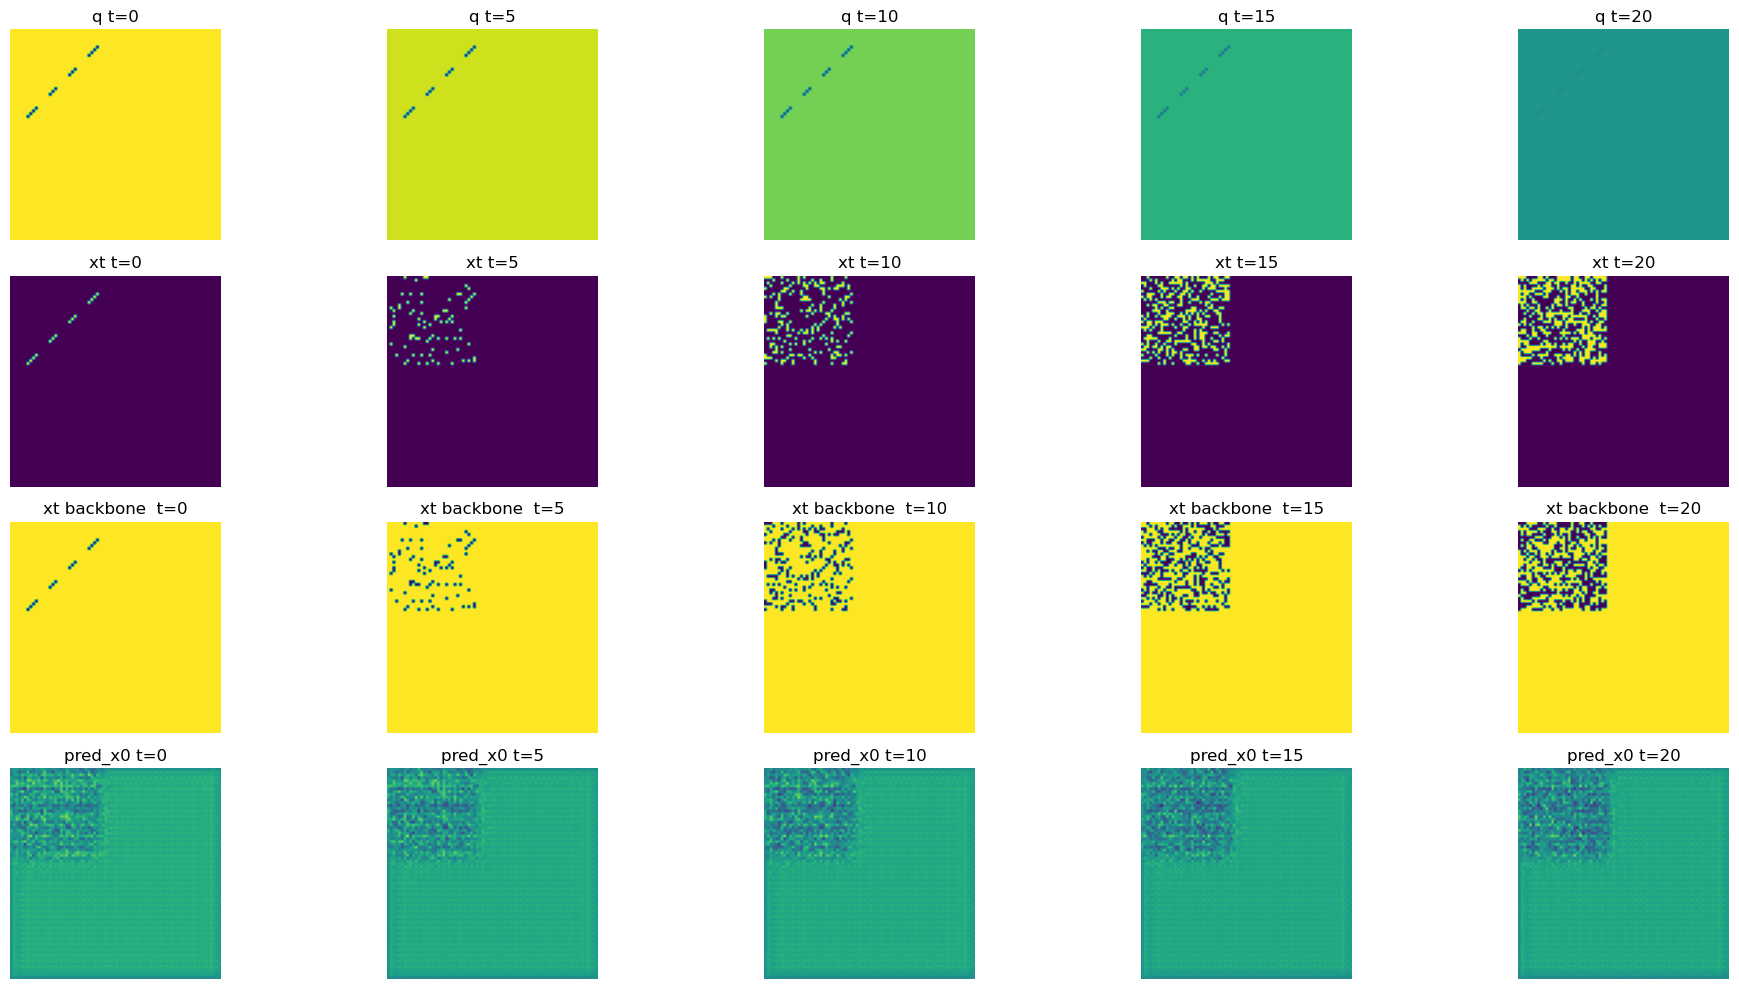

In [73]:
times = [tr.tensor([t]) for t in range(0, model.time_steps, 5)]
qt = [model.q_pred(x0_real, time_t) for time_t in times]
xt_t = [model.q_sample(x0_real, time_t, lengths=lengths_real) for time_t in times]
xt_t_backbone = []
for xt_i, time_t in zip(xt_t, times):
    xt_backbone_i, _ = model._prepare_backbone_inputs(xt_i, cond, lengths=lengths_real)
    xt_t_backbone.append(xt_backbone_i)
pred_t = [model.predict_start(xt_i, time_t, cond, lengths=lengths_real) for xt_i, time_t in zip(xt_t, times)]

fig, axes = plt.subplots(4, len(times), figsize=(4 * len(times), 10))
for i, time_t in enumerate(times):
    print(f" shapes: q: {qt[i].shape}, xt: {xt_t[i].shape}, xt_backbone: {xt_t_backbone[i].shape}, pred: {pred_t[i].shape}")
    axes[0, i].imshow(qt[i][0, 0], vmin=0, vmax=1)
    axes[0, i].set_title(f'q t={time_t.item()}')
    axes[1, i].imshow(xt_t[i][0], vmin=0, vmax=1)
    axes[1, i].set_title(f'xt t={time_t.item()}')
    axes[2, i].imshow(xt_t_backbone[i][0, 0], vmin=0, vmax=1)
    axes[2, i].set_title(f'xt backbone  t={time_t.item()}')
    axes[3, i].imshow(pred_t[i][0, 0].detach().numpy(), vmin=0, vmax=1)
    axes[3, i].set_title(f'pred_x0 t={time_t.item()}')
for ax in axes.flatten():
    ax.axis('off')
fig.tight_layout()
plt.show()


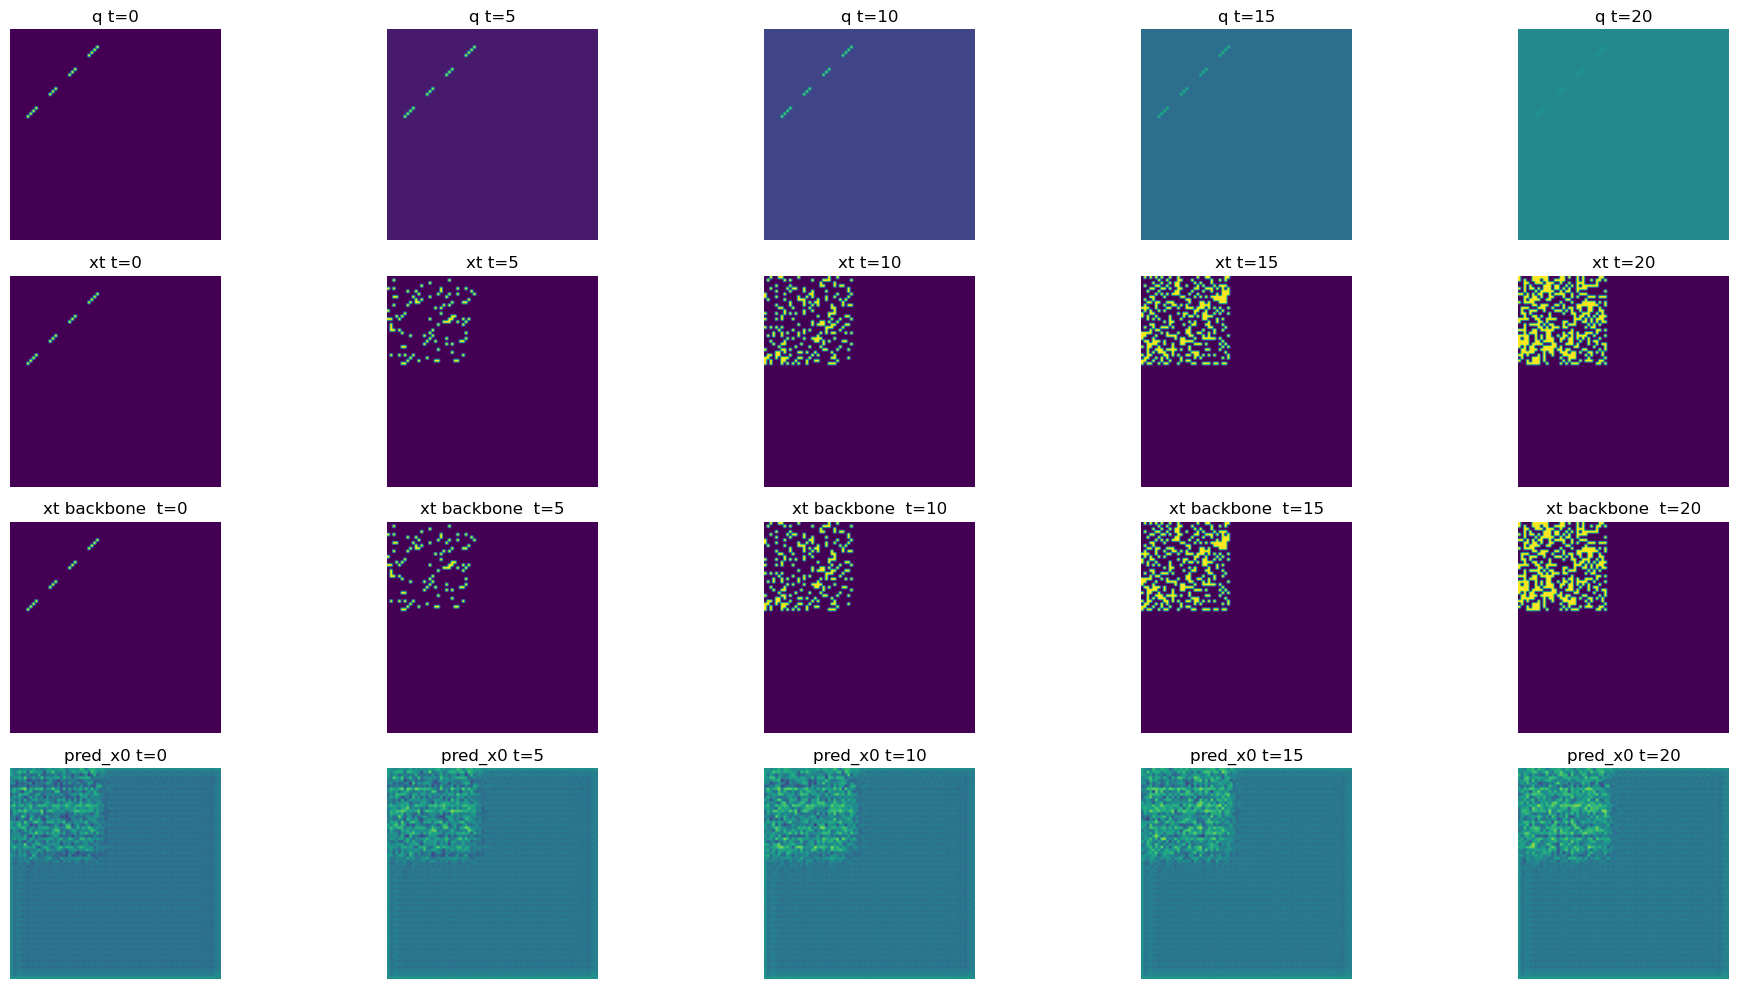

In [74]:
times = [tr.tensor([t]) for t in range(0, model.time_steps, 5)]
fig, axes = plt.subplots(4, len(times), figsize=(4 * len(times), 10))
for i, time_t in enumerate(times):
    qt = model.q_pred(x0_real, time_t)
    xt_t = model.q_sample(x0_real, time_t, lengths=lengths_real)
    xt_t_backbone, _ = model._prepare_backbone_inputs(xt_t, cond, lengths=lengths_real)
    pred_t = model.predict_start(xt_t, time_t, cond, lengths=lengths_real)
    axes[0, i].imshow(qt[0, 1], vmin=0, vmax=1)
    axes[0, i].set_title(f'q t={time_t.item()}')
    axes[1, i].imshow(xt_t[0], vmin=0, vmax=1)
    axes[1, i].set_title(f'xt t={time_t.item()}')
    axes[2, i].imshow(xt_t_backbone[0, 1], vmin=0, vmax=1)
    axes[2, i].set_title(f'xt backbone  t={time_t.item()}')
    axes[3, i].imshow(pred_t[0, 1].detach().numpy(), vmin=0, vmax=1)
    axes[3, i].set_title(f'pred_x0 t={time_t.item()}')
for ax in axes.flatten():
    ax.axis('off')
fig.tight_layout()
plt.show()


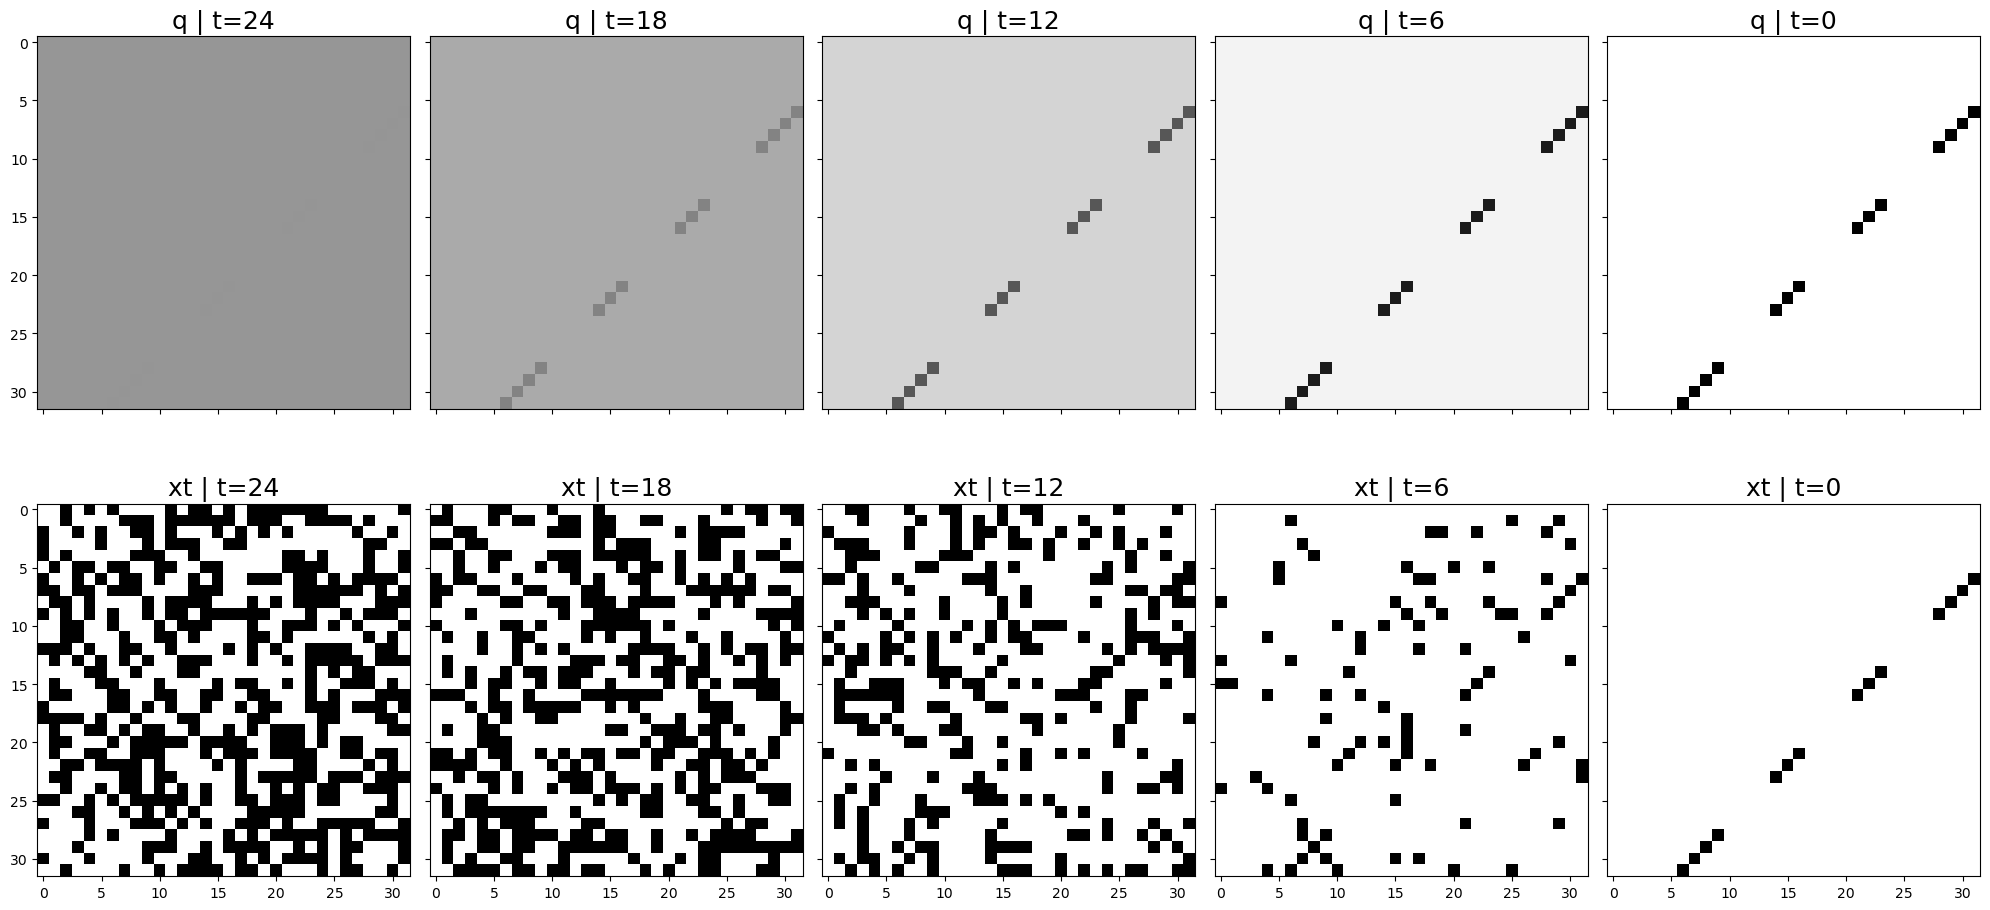

In [95]:
times = [tr.tensor([t]) for t in reversed(range(0, model.time_steps, 6))]
fig, axes = plt.subplots(2, len(times), figsize=(4 * len(times), 10), sharex=True, sharey=True)
for i, time_t in enumerate(times):
    qt = model.q_pred(x0_real, time_t)
    xt_t = model.q_sample(x0_real, time_t, lengths=lengths_real)
    xt_t_backbone, _ = model._prepare_backbone_inputs(xt_t, cond, lengths=lengths_real)
    pred_t = model.predict_start(xt_t, time_t, cond, lengths=lengths_real)
    plot_qt = qt[0, 1][:seq_len, :seq_len].detach().numpy()
    plot_xt_t = xt_t[0][:seq_len, :seq_len].detach().numpy()
    plot_xt_t_backbone = xt_t_backbone[0, 1][:seq_len, :seq_len].detach().numpy()
    plot_pred_t = pred_t[0, 1][:seq_len, :seq_len].detach().numpy()

    axes[0, i].imshow(plot_qt, vmin=0, vmax=1, cmap='Greys')
    axes[0, i].set_title(f'q | t={time_t.item()}', fontsize = 18)
    axes[1, i].imshow(plot_xt_t, vmin=0, vmax=1, cmap='Greys')
    axes[1, i].set_title(f'xt | t={time_t.item()}', fontsize = 18)
    # axes[2, i].imshow(plot_xt_t_backbone, vmin=0, vmax=1, cmap='Greys')
    # axes[2, i].set_title(f'xt backbone  t={time_t.item()}')
    # axes[3, i].imshow(plot_pred_t, vmin=0, vmax=1, cmap='Greys')
    # axes[3, i].set_title(f'pred_x0 t={time_t.item()}')
# for ax in axes.flatten():
#     ax.axis('off')
fig.tight_layout()
plt.show()


In [75]:
print('contact padded:', x0_real[0, :, seq_len, seq_len])
print('conditioning padded:', cond[0, :4, seq_len, seq_len])
print('mask padded:', mask_real[0, 0, seq_len, seq_len])


contact padded: tensor([1., 0.])
conditioning padded: tensor([0., 0., 0., 0.])
mask padded: tensor(False)


In [76]:
true_posterior = model.q_posterior(x0_real, xt, time)
pred_posterior = model.q_posterior(pred_x0, xt, time)
eps = 1e-8
true_posterior = tr.clamp(true_posterior, min=eps, max=1.0)
pred_posterior = tr.clamp(pred_posterior, min=eps, max=1.0)
kl = true_posterior * (tr.log(true_posterior) - tr.log(pred_posterior))
kl_pixelwise = tr.sum(kl, dim=1)
kl_lengths = model.multinomial_kl(true_posterior, pred_posterior, lengths=lengths_real)

print('kl_pixelwise shape:', kl_pixelwise.shape)
print('raw padded kl:', kl_pixelwise[0, seq_len, seq_len])
print('masked with multiplication:', (kl_pixelwise * mask_real.squeeze(1))[0, seq_len, seq_len])
print('valid mean with lengths:', kl_lengths)


kl_pixelwise shape: torch.Size([1, 76, 76])
raw padded kl: tensor(0.0172, grad_fn=<SelectBackward0>)
masked with multiplication: tensor(0., grad_fn=<SelectBackward0>)
valid mean with lengths: tensor([0.0358], grad_fn=<StackBackward0>)


In [77]:
print('Regla de implementacion:')
print('- Batch padded con ceros; contact_oh fuera de longitud queda [1, 0]')
print('- lengths define la region valida')
print('- Backbone recibe conditioning=0 y xt/contact=[1, 0] fuera de lengths')
print('- Loss y sampling solo consideran pixeles validos')


Regla de implementacion:
- Batch padded con ceros; contact_oh fuera de longitud queda [1, 0]
- lengths define la region valida
- Backbone recibe conditioning=0 y xt/contact=[1, 0] fuera de lengths
- Loss y sampling solo consideran pixeles validos


## 7. Reverse sampling con `lengths`


In [78]:
p_step = model.p_sample(xt, time, cond, lengths=lengths_real)

print('p_sample valid:', p_step[0, 0, 0])
print('p_sample padded:', p_step[0, seq_len, seq_len])


p_sample valid: tensor(1)
p_sample padded: tensor(0)


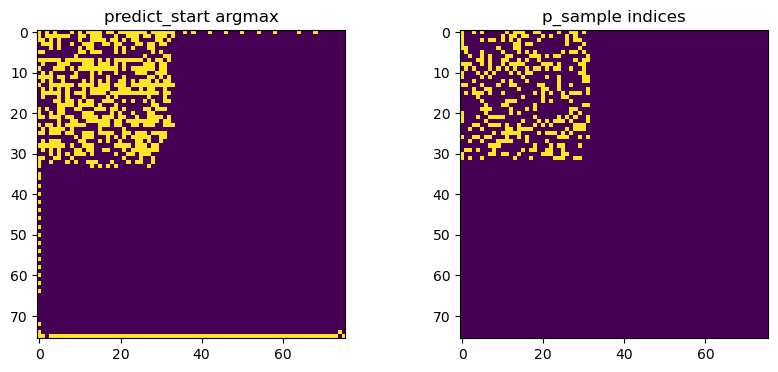

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(tr.argmax(pred_x0[0], dim=0))
axes[0].set_title('predict_start argmax')
axes[1].imshow(p_step[0])
axes[1].set_title('p_sample indices')
plt.show()


## 8. Sampling completo


In [80]:
pred_x0 = model.predict_start(xt, time, cond, lengths=lengths_real)
sample_full = model.sample(cond, lengths=lengths_real)

print('predict_start padded:', pred_x0[0, :, seq_len, seq_len], 'sum =', pred_x0[0, :, seq_len, seq_len].sum())
print('sample padded:', sample_full[0, seq_len, seq_len])


predict_start padded: tensor([0.5229, 0.4771], grad_fn=<SelectBackward0>) sum = tensor(1., grad_fn=<SumBackward0>)
sample padded: tensor(0)


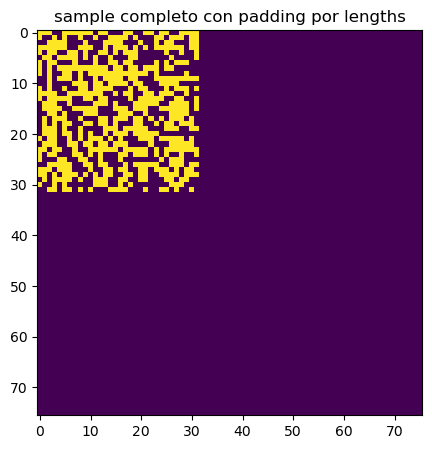

In [81]:
tr.manual_seed(0)
sample_full = model.sample(cond, lengths=lengths_real)

plt.figure(figsize=(6, 5))
plt.imshow(sample_full[0])
plt.title('sample completo con padding por lengths')
plt.show()
